# Does Daylight Saving Time Reduce Property Crime?

**Project:** IDS 701 — Problem Solving with Data Science  
**Design:** California (treated) vs. Arizona (control)  
**Robustness:** CA + Utah vs. Arizona  

---
**Notebook structure**
1. Data and Setup
2. Identification Strategy
3. EDA — Descriptive Trends
4. Stage 1 — Mechanism (Triple-Difference)
5. Stage 2 — Main DiD Results *(primary finding)*
6. Robustness Checks
7. Conclusion


## Section 0 — Data and Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Project root ────────────────────────────────────────────────────────
_root = Path.cwd()
for _ in range(4):
    if (_root / 'data').exists() and (_root / 'scripts').exists():
        break
    _root = _root.parent
os.chdir(_root)

# ── Plot style ───────────────────────────────────────────────────────────
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['axes.spines.top']   = False
mpl.rcParams['axes.spines.right'] = False

# ── Constants ────────────────────────────────────────────────────────────
CRIMES       = ['burglary', 'motor_vehicle_theft']
CRIME_LABELS = {'burglary': 'Burglary', 'motor_vehicle_theft': 'Motor Vehicle Theft'}

# Blue = burglary, Orange = motor vehicle theft, Green = CA+UT robustness
CRIME_COLORS = {'burglary': '#1f77b4', 'motor_vehicle_theft': '#ff7f0e'}
STATE_COLORS = {'CA': '#1f77b4', 'AZ': '#d62728'}
ROBUST_COLOR = '#2ca02c'   # green: CA+UT robustness only
YEAR_STYLES  = {2022: ('--', 0.40), 2023: (':', 0.40), 2024: ('-.', 0.40)}

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ── DST transition dates ─────────────────────────────────────────────────
def spring_forward(year):
    d0 = date(year, 3, 1)
    return d0 + timedelta(days=(6 - d0.weekday()) % 7) + timedelta(days=7)

def fall_back(year):
    d0 = date(year, 11, 1)
    return d0 + timedelta(days=(6 - d0.weekday()) % 7)

DST_DATES = {y: {'start': spring_forward(y), 'end': fall_back(y)} for y in [2022, 2023, 2024]}
DST_SPRING_2024 = pd.Timestamp('2024-03-10')

# ── File paths ────────────────────────────────────────────────────────────
DAILY_PATH  = Path('data/processed/crime/focus_states_daily_county_counts.csv')
POP_PATH    = Path('data/processed/population/focus_states_county_population_2020_2024_long.csv')
HOURLY_PATH = Path('data/processed/crime/focus_states_hourly_structured.csv')
PANEL_PATH  = Path('data/processed/model/focus_states_daily_county_model_panel_2022_2024.csv')

print('Working dir:', Path.cwd())
print('DST dates:')
for y, d in DST_DATES.items():
    print(f'  {y}: spring-forward={d["start"]}  fall-back={d["end"]}')
print('\nFiles OK:', all(p.exists() for p in [DAILY_PATH, POP_PATH, HOURLY_PATH, PANEL_PATH]))


Working dir: /Users/shellyy/Desktop/IDS_701/IDS701_UDS_Final_Project
DST dates:
  2022: spring-forward=2022-03-13  fall-back=2022-11-06
  2023: spring-forward=2023-03-12  fall-back=2023-11-05
  2024: spring-forward=2024-03-10  fall-back=2024-11-03

Files OK: True


---
## Section 1 — Identification Strategy

### Design

| Role | State | Reason |
|------|-------|--------|
| **Treated** | California (CA) | Observes DST each year (mid-March → early November) |
| **Control** | Arizona (AZ) | Does **not** observe DST — clocks never change |
| **Robustness** | Utah (UT) | Observes DST like CA; used only to test treated-group sensitivity |

### Parallel-trends assumption

> **CA and AZ would follow similar crime trends in the absence of DST.**

**Why Arizona is a credible control:**
- Arizona is the only contiguous U.S. state that does not observe DST (Navajo Nation excluded).
- Both states share similar climate, a shared border, comparable reporting systems, and similar
  property-crime types.
- AZ provides a clean natural experiment: its crime trends respond to the same seasonal forces
  (weather, economy, tourism) but are **never** shifted by the clock change.

### Treatment variable

`in_dst_window = 1` when California has sprung forward (mid-March through early November in each year).
Arizona always has `in_dst_window = 0`.

### What we estimate

- **Stage 1** (Section 4): Does DST shift *when* crimes occur within the day?  
  Identified via a **triple-difference** comparing the time-of-day pattern shift in CA
  relative to AZ around the spring-forward date.

- **Stage 2** (Section 5): Does DST change *total* daily crime levels?  
  Identified via **TWFE DiD** with county and year-month fixed effects,
  SE clustered at the county level.


---
## Section 2 — EDA: Descriptive Trends

Descriptive only. No causal claims here — these plots motivate the design and
give a feel for the raw crime patterns in each state.


In [2]:
from matplotlib.lines import Line2D

# ── Load daily crime and population data ─────────────────────────────────
daily = pd.read_csv(DAILY_PATH, parse_dates=['incident_date'])
pop   = pd.read_csv(POP_PATH)
pop['data_year'] = pop['data_year'].astype(int)

# Exclude Navajo Nation AZ counties using the flag in the population file
excl    = pop['proposal_excluded_az_county'].fillna(False)
pop_use = pd.concat([pop[pop['state'] != 'AZ'], pop[(pop['state'] == 'AZ') & (~excl)]], ignore_index=True)
st_pop  = pop_use.groupby(['state', 'data_year'], as_index=False)['population'].sum()

# Filter to CA, AZ, UT; target crimes; 2022-2024
PLOT_STATES = ['CA', 'AZ', 'UT']
d = daily[
    daily['state'].isin(PLOT_STATES) &
    daily['crime_type'].isin(CRIMES) &
    daily['incident_date'].dt.year.between(2022, 2024)
].copy()
d['year'] = d['incident_date'].dt.year.astype(int)

# Aggregate to state level and compute rate
st_day = (
    d.groupby(['state', 'year', 'incident_date', 'crime_type'], as_index=False)['incident_count'].sum()
     .merge(st_pop.rename(columns={'data_year': 'year'}), on=['state', 'year'], how='left')
)
st_day['rate_per_100k'] = st_day['incident_count'] / st_day['population'] * 100_000.0
st_day['month']         = st_day['incident_date'].dt.month

# Spring-forward dates as Timestamps (for bottom-row window plot)
sf_dates = {y: pd.Timestamp(DST_DATES[y]['start']) for y in [2022, 2023, 2024]}
def days_from_sf(row):
    return (row['incident_date'] - sf_dates[row['year']]).days
st_day['days_from_sf'] = st_day.apply(days_from_sf, axis=1)

# Month ordering: Non-DST (Nov–Feb) on left, DST (Mar–Oct) on right
MONTH_ORDER  = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
MONTH_XLABELS = ['Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']
month_to_x   = {m: i for i, m in enumerate(MONTH_ORDER)}
st_day['x_pos'] = st_day['month'].map(month_to_x)

# State colors — add UT
STATE_COLORS_3 = {'CA': '#1f77b4', 'AZ': '#d62728', 'UT': '#2ca02c'}

print(f'State-day rows: {len(st_day):,}')
print(f'States: {sorted(st_day["state"].unique())}')
print(f'Years:  {sorted(st_day["year"].unique())}')

State-day rows: 6,576
States: ['AZ', 'CA', 'UT']
Years:  [np.int64(2022), np.int64(2023), np.int64(2024)]


NameError: name 'YEAR_STYLES' is not defined

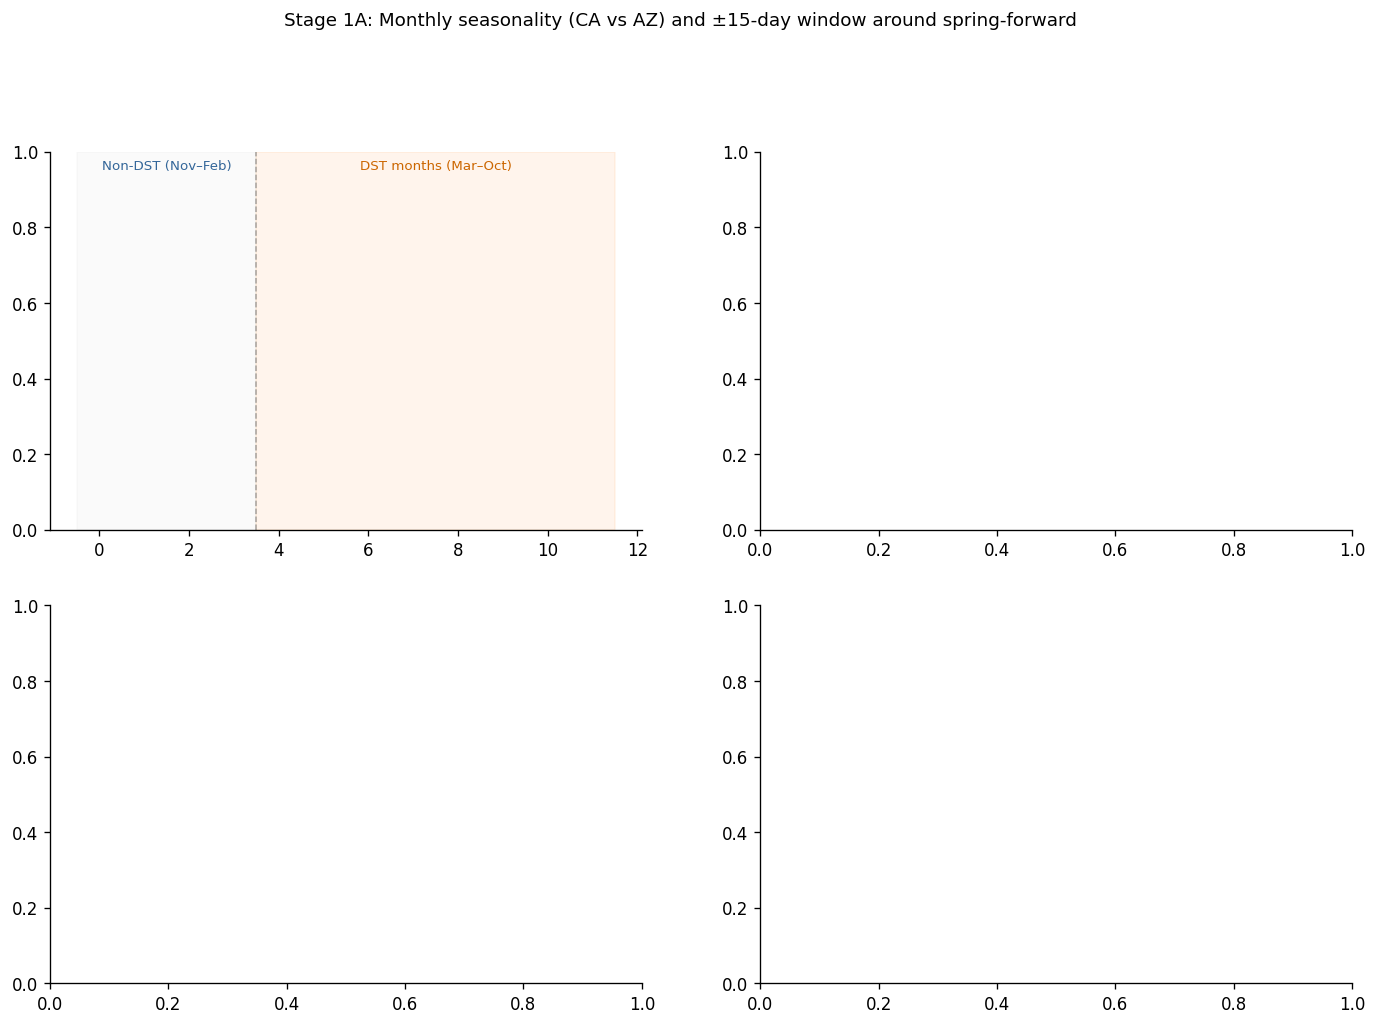

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Stage 1A: Monthly seasonality (CA vs AZ) and ±15-day window around spring-forward',
    fontsize=11, y=1.01,
)

# --- REMOVE UT HERE ---
STATE_LINE_LABELS = {
    'CA': 'CA avg — treated, observes DST',
    'AZ': 'AZ avg — control, no DST',
}

# Only keep CA and AZ
PLOT_STATES = ['CA', 'AZ']

for col, crime in enumerate(CRIMES):
    sub = st_day[st_day['crime_type'] == crime].copy()

    # ── TOP ROW ─────────────────────────────────────────────
    ax = axes[0][col]
    ax.axvspan(-0.5,  3.5, alpha=0.10, color='lightgray', zorder=0)
    ax.axvspan( 3.5, 11.5, alpha=0.08, color='#ff7f0e', zorder=0)
    ax.axvline(3.5, color='gray', lw=0.9, ls='--', alpha=0.7)

    ax.text(1.5, 0.98, 'Non-DST (Nov–Feb)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#336699', ha='center', va='top')
    ax.text(7.5, 0.98, 'DST months (Mar–Oct)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#cc6600', ha='center', va='top')

    # Individual year lines
    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_sub = (
                sub[(sub['state'] == state) & (sub['year'] == year)]
                .groupby('x_pos')['rate_per_100k']
                .mean()
                .reset_index()
                .sort_values('x_pos')
            )
            ax.plot(
                yr_sub['x_pos'], yr_sub['rate_per_100k'],
                color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2
            )

    # 3-year average
    avg = sub.groupby(['state', 'x_pos'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = avg[avg['state'] == state].sort_values('x_pos')
        ax.plot(
            s['x_pos'], s['rate_per_100k'],
            color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3
        )

    ax.set_title(f'{CRIME_LABELS[crime]}\nCA vs AZ seasonality comparison', fontsize=10)
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_XLABELS, fontsize=8)
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylabel('Avg daily rate per 100k')

    # Legend
    state_h = [
        Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
               label=STATE_LINE_LABELS[s]) for s in PLOT_STATES
    ]
    year_h  = [
        Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
               label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()
    ]
    ax.legend(handles=state_h + year_h, fontsize=7.5, framealpha=0.5, ncol=2)

    # ── BOTTOM ROW ─────────────────────────────────────────
    ax2 = axes[1][col]
    win_sub = sub[sub['days_from_sf'].between(-15, 15)].copy()

    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_win = (
                win_sub[(win_sub['state'] == state) & (win_sub['year'] == year)]
                .groupby('days_from_sf')['rate_per_100k']
                .mean()
                .reset_index()
                .sort_values('days_from_sf')
            )
            ax2.plot(
                yr_win['days_from_sf'], yr_win['rate_per_100k'],
                color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2
            )

    win_avg = win_sub.groupby(['state', 'days_from_sf'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = win_avg[win_avg['state'] == state].sort_values('days_from_sf')
        ax2.plot(
            s['days_from_sf'], s['rate_per_100k'],
            color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3
        )

    ax2.axvline(0, color='black', lw=1.5, ls='--')
    ax2.axvspan(-15, 0, alpha=0.05, color='#4a90d9')
    ax2.axvspan(0, 15, alpha=0.05, color='#ff7f0e')

    ax2.text(-7.5, 0.04, 'Before DST', transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#336699', ha='center', va='bottom')
    ax2.text(7.5, 0.04, 'After DST', transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#cc6600', ha='center', va='bottom')

    ax2.set_title(f'{CRIME_LABELS[crime]}\nNo jump at spring-forward — CA vs AZ (±15 days)', fontsize=10)
    ax2.set_xlabel('Days from spring-forward')
    ax2.set_ylabel('Avg daily rate per 100k')

    state_h2 = [
        Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
               label=f'{s} avg') for s in PLOT_STATES
    ]
    year_h2  = [
        Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
               label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()
    ]
    clock_h  = [Line2D([0],[0], color='black', lw=1.5, ls='--',
                       label='Clocks spring forward')]

    ax2.legend(handles=state_h2 + year_h2 + clock_h,
               fontsize=7.5, framealpha=0.5, ncol=2)

fig.text(
    0.5, -0.01,
    'Thin lines = individual years. Thick solid = 3-year average.',
    ha='center', fontsize=8.5, color='#555'
)

plt.tight_layout()
plt.show()

---
## Section 3 — Stage 1: Mechanism (Time-of-Day Displacement)

**Purpose:** Does DST shift *when* crimes occur within the day, or not?

**Method — Triple-difference (DDD):**

```
crime_count ~ treated_state × post_dst × C(time_bucket, ref='late_night')
            + C(county_fips) + C(day_of_week) + C(offense_type)
```

The triple interaction `treated × post_dst × bucket` measures whether California
shifts its within-day crime distribution differently from Arizona after the clock change.

**Time-of-day buckets (light-regime motivated):**

| Bucket | Hours | Expected DST effect |
|--------|-------|---------------------|
| `morning_dark` | 5–8h | Darker mornings → possible crime increase |
| `daytime` | 9–17h | Light regardless → reference group |
| `evening_light` | 18–21h | Lighter evenings → possible crime decrease |
| `late_night` | 0–4h, 22–23h | Dark regardless → regression reference |

> **Note on within-state regressions:** Within-state models absorb `post_dst` via
> county fixed effects when the treatment timing is identical for all counties in a state,
> producing infinite standard errors. Only the triple-difference is shown.

**Data:** Hourly crime counts around the 2024 spring-forward (±28 days).
**Main model:** CA (treated) vs AZ (control).
**Robustness:** CA + UT (treated) vs AZ (control).


In [ ]:
# ── Load hourly data, filter to CA, UT (treated) and AZ (control) ────────
_raw = pd.read_csv(HOURLY_PATH, low_memory=False)
_raw = _raw[_raw['state'].isin(['CA', 'UT', 'AZ'])].copy()

TREATED_STATES = ['CA', 'UT']

# Reconstruct date from year/month/day columns
df_h = _raw.assign(
    date=lambda d: pd.to_datetime(d[['year', 'month', 'day']]),
).assign(
    post_dst=lambda d: (d['date'] >= DST_SPRING_2024).astype(int),
    days_from_dst=lambda d: (d['date'] - DST_SPRING_2024).dt.days,
    day_of_week=lambda d: d['date'].dt.dayofweek,
    treated_state=lambda d: d['state'].isin(TREATED_STATES).astype(int),
)

# ±28-day window around spring-forward
WINDOW_DAYS = 28
win = df_h[df_h['days_from_dst'].between(-WINDOW_DAYS, WINDOW_DAYS)].copy()

# Time-of-day buckets (light-regime motivated)
# morning_dark (5–8h):   sunrise ~1h later after spring-forward → darker mornings
# daytime (9–17h):       light regardless of DST (regression reference)
# evening_light (18–21h):sunset ~1h later after spring-forward → lighter evenings
# late_night (0–4h, 22–23h): dark regardless
BUCKET_DEF = {
    'morning_dark':  range(5, 9),
    'daytime':       range(9, 18),
    'evening_light': range(18, 22),
    'late_night':    list(range(0, 5)) + list(range(22, 24)),
}
hour_to_bucket = {h: b for b, hrs in BUCKET_DEF.items() for h in hrs}
win['time_bucket'] = win['hour'].map(hour_to_bucket)

n_treated = win[win['treated_state'] == 1]['county_fips'].nunique()
n_control = win[win['treated_state'] == 0]['county_fips'].nunique()
print(f'Window: {win["date"].min().date()} to {win["date"].max().date()}')
print(f'Treated states (CA+UT): {sorted(win[win["treated_state"]==1]["state"].unique())}')
print(f'Treated counties: {n_treated}')
print(f'Control counties (AZ): {n_control}')
print(f'Rows in window: {len(win):,}')
# Also track CA-only treated for triple-diff main model
win['treated_state_main']   = (win['state'] == 'CA').astype(int)
win['treated_state_robust'] = win['treated_state']   # CA+UT (same as treated_state)


Window: 2024-02-11 to 2024-04-07
Rows: 21627
Counties by state:
state
AZ    10
CA    57
UT    22
Name: county_fips, dtype: int64


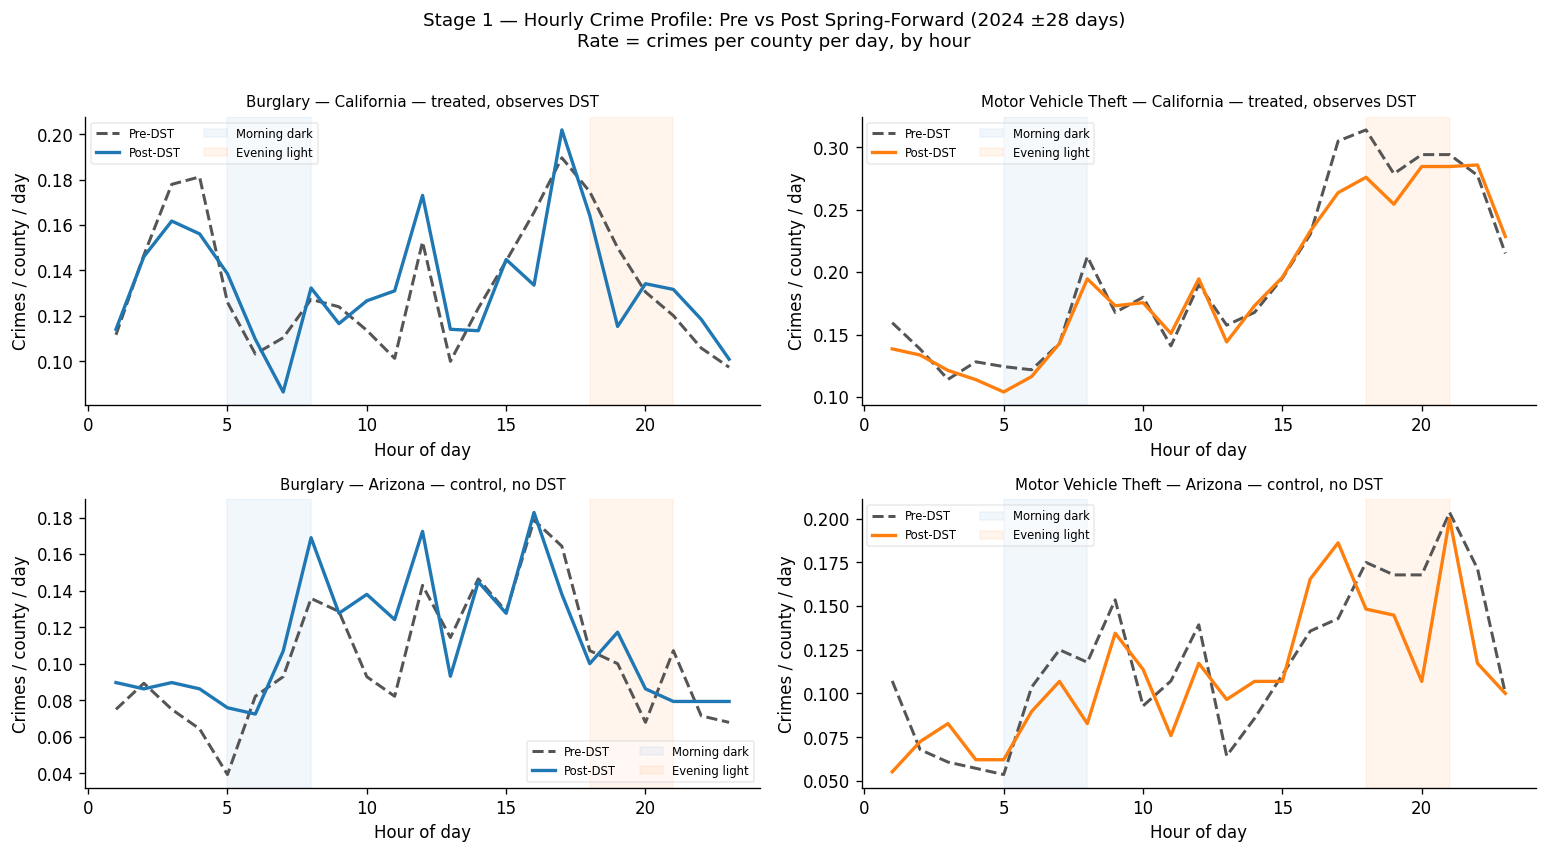

In [ ]:
# Hourly profile — two rows:
# Row 1: ±28-day window, pre vs post (two clean lines), one panel per group
# Row 2: Full-year seasonal (pre-DST vs post-DST), by crime type
#
# Both rows use: sum(crime_count) / (n_counties × n_days)  [teammate's normalization]

hours_plot = list(range(1, 24))   # exclude hour 0

# ── Hourly avg helper (teammate's method) ────────────────────────────────
def hourly_avg(df, treated):
    sub   = df[df['treated_state'] == treated]
    n_c   = sub['county_fips'].nunique()
    n_pre  = sub[sub['post_dst'] == 0]['date'].nunique()
    n_post = sub[sub['post_dst'] == 1]['date'].nunique()
    agg = sub.groupby(['hour', 'post_dst'])['crime_count'].sum().unstack(fill_value=0)
    agg['pre']  = agg[0] / max(n_c * n_pre,  1)
    agg['post'] = agg[1] / max(n_c * n_post, 1)
    return agg.reindex(range(24))

prof_tr = hourly_avg(win, 1)   # CA + UT
prof_az = hourly_avg(win, 0)   # AZ

n_treated_counties = win[win['treated_state'] == 1]['county_fips'].nunique()
n_control_counties = win[win['treated_state'] == 0]['county_fips'].nunique()

# ── Seasonal hourly avg (same normalization) ──────────────────────────────
h_full = df_h[(df_h['treated_state'] == 1) & (df_h['hour'] != 0)].copy()
h_full['period'] = h_full['month'].apply(lambda m: 'DST' if 3 <= m <= 11 else 'standard')

seas_rows = []
for period in ['DST', 'standard']:
    sub_p = h_full[h_full['period'] == period]
    n_c = sub_p['county_fips'].nunique()
    n_d = sub_p[['year', 'month', 'day']].drop_duplicates().shape[0]
    for offense in CRIMES:
        sub = sub_p[sub_p['offense_type'] == offense]
        agg = sub.groupby('hour')['crime_count'].sum() / max(n_c * n_d, 1)
        for hour, val in agg.items():
            seas_rows.append({'period': period, 'offense_type': offense,
                              'hour': hour, 'avg': val})
seas_avg = pd.DataFrame(seas_rows)

PERIOD_COLORS_Q2 = {'DST': '#ff7f0e', 'standard': '#333333'}
PERIOD_LABELS_Q2 = {'DST': 'Post-DST avg (Mar–Nov)', 'standard': 'Pre-DST avg (Dec–Feb)'}

# ── Build figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Stage 1B: Hourly Crime Profile\n'
    'Row 1: ±28-day spring-forward window.  Row 2: Full-year seasonal (CA+UT).',
    fontsize=11, y=1.01,
)

# ── ROW 1 ─────────────────────────────────────────────────────────────────
panel_specs = [
    (prof_tr, f'Treated: CA + UT  ({n_treated_counties} counties)'),
    (prof_az, f'Control: AZ  (no DST change, {n_control_counties} counties)'),
]
for col, (prof, panel_title) in enumerate(panel_specs):
    ax = axes[0][col]
    ax.plot(hours_plot, prof.loc[hours_plot, 'pre'].values,
            color='steelblue', lw=2, marker='o', ms=4, label='Pre-DST  (days −28 to −1)')
    ax.plot(hours_plot, prof.loc[hours_plot, 'post'].values,
            color='tomato',    lw=2, marker='s', ms=4, label='Post-DST (days 0 to +28)')
    ax.axvspan(4.5,  8.5,  alpha=0.12, color='navy', label='Morning dark (5–8h)')
    ax.axvspan(17.5, 21.5, alpha=0.12, color='gold', label='Evening light (18–21h)')
    ax.set_title(panel_title, fontsize=10)
    ax.set_xlabel('Hour of day (local clock; hour 0 excluded — midnight imputation artifact)')
    ax.set_ylabel('Avg crimes per county per day')
    ax.set_xticks(range(1, 24, 2))
    ax.legend(fontsize=8, ncol=2, loc='upper left')

# ── ROW 2 ─────────────────────────────────────────────────────────────────
for col, crime in enumerate(CRIMES):
    ax2 = axes[1][col]
    for period, color in PERIOD_COLORS_Q2.items():
        s = seas_avg[(seas_avg['offense_type'] == crime) &
                     (seas_avg['period'] == period)].sort_values('hour')
        ax2.plot(s['hour'], s['avg'], color=color, lw=2.4, marker='o', ms=3,
                 label=PERIOD_LABELS_Q2[period])
    ax2.axvspan(17, 21, alpha=0.2, color='#4a90d9', label='Evening 5–9pm')
    ax2.axvspan(5,  9,  alpha=0.2, color='#aaaaaa', label='Morning 5–9am')
    ax2.set_title(CRIME_LABELS[crime], fontsize=10)
    ax2.set_xlabel('Hour of day')
    ax2.set_xticks(range(0, 24, 3))
    ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30, fontsize=8)
    if col == 0:
        ax2.set_ylabel('Avg crimes per county per day')
    ax2.legend(fontsize=8, framealpha=0.5)

plt.tight_layout()
plt.show()

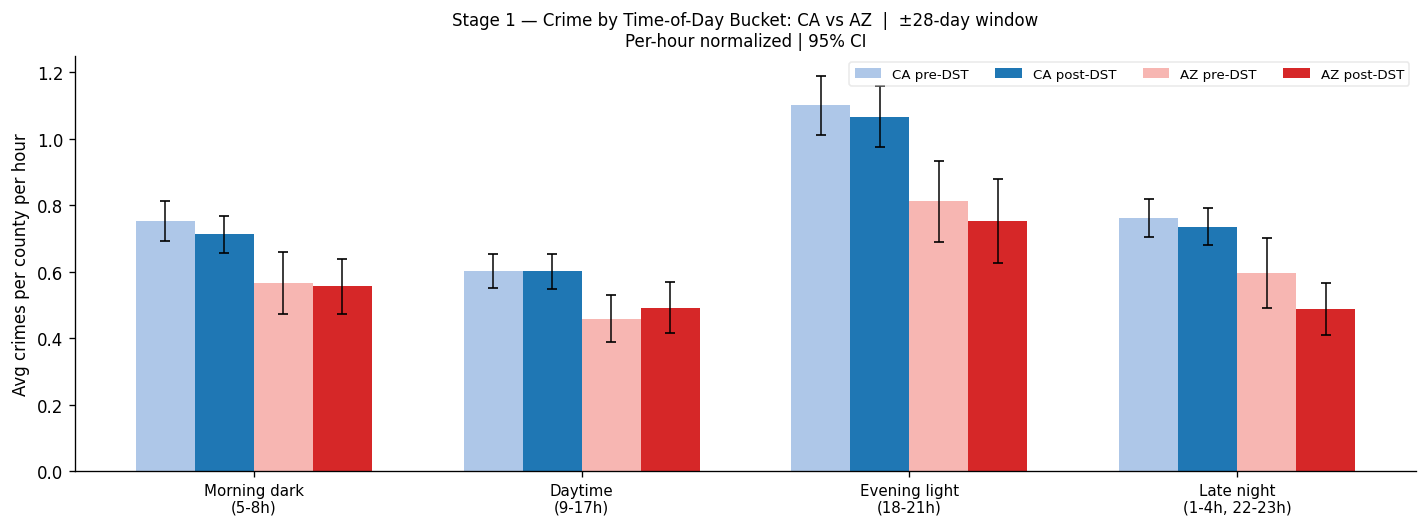

In [ ]:
# Stage 1C — Time-of-Day Bucket Analysis
# Buckets normalized to per-hour so unequal-size buckets are comparable.
# late_night hours: 1-4 + 22-23 = 6h (hour 0 excluded); morning_dark/evening_light = 4h; daytime = 9h

BUCKET_ORDER  = ['morning_dark', 'daytime', 'evening_light', 'late_night']
BUCKET_LABELS = {
    'morning_dark':  'Morning dark\n(5–8h)',
    'daytime':       'Daytime\n(9–17h)',
    'evening_light': 'Evening light\n(18–21h)',
    'late_night':    'Late night\n(1–4h, 22–23h)',
}
BUCKET_HOURS = {'morning_dark': 4, 'daytime': 9, 'evening_light': 4, 'late_night': 6}

# ── Data prep: daily bucket total per county, then mean/SE across county-days ──
win_nz = win[win['hour'] != 0].copy()
daily_bkt = (
    win_nz.groupby(['state', 'county_fips', 'post_dst', 'time_bucket', 'date'],
                   as_index=False)['crime_count'].sum()
)
bucket_agg = (
    daily_bkt.groupby(['state', 'post_dst', 'time_bucket'], as_index=False)
    .agg(mean_count=('crime_count', 'mean'),
         se_count=('crime_count', lambda x: x.std() / np.sqrt(len(x))))
)
# Normalize to per-hour
bucket_agg['mean_ph'] = bucket_agg.apply(
    lambda r: r['mean_count'] / BUCKET_HOURS[r['time_bucket']], axis=1)
bucket_agg['se_ph'] = bucket_agg.apply(
    lambda r: r['se_count']   / BUCKET_HOURS[r['time_bucket']], axis=1)



In [ ]:
# Stage 1C (b): CA + AZ comparison, same per-hour normalization

PERIOD_LABELS_1C = {0: 'Pre-DST', 1: 'Post-DST'}
BOX_COLORS_1C = {
    ('CA', 0): '#aec7e8', ('CA', 1): '#1f77b4',
    ('AZ', 0): '#f7b6b2', ('AZ', 1): '#d62728',
}
BOX_LABELS_1C = {
    ('CA', 0): 'CA pre-DST', ('CA', 1): 'CA post-DST',
    ('AZ', 0): 'AZ pre-DST', ('AZ', 1): 'AZ post-DST',
}

x = np.arange(len(BUCKET_ORDER))
w = 0.18
offsets = {'CA_0': -1.5*w, 'CA_1': -0.5*w, 'AZ_0': 0.5*w, 'AZ_1': 1.5*w}

fig, ax = plt.subplots(figsize=(13, 5))
for state in ['CA', 'AZ']:
    for period in [0, 1]:
        sub = (bucket_agg[(bucket_agg['state'] == state) & (bucket_agg['post_dst'] == period)]
               .set_index('time_bucket').reindex(BUCKET_ORDER))
        offset = offsets[f'{state}_{period}']
        ax.bar(x + offset, sub['mean_ph'], w,
               color=BOX_COLORS_1C[(state, period)], label=BOX_LABELS_1C[(state, period)])
        ax.errorbar(x + offset, sub['mean_ph'], yerr=1.96*sub['se_ph'],
                    fmt='none', color='black', capsize=4, lw=1)

ax.axvspan(-0.5, 0.5, alpha=0.08, color='#4a90d9', zorder=0)
ax.axvspan( 1.5, 2.5, alpha=0.08, color='#ff7f0e', zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER], fontsize=9)
ax.set_ylabel('Avg crimes per county per hour')
ax.set_title(
    'Stage 1C (b): Crime by Time-of-Day Bucket — CA (treated) vs AZ (control)\n'
    '±28-day window | per-hour normalized | 95% CI | '
    'Blue shading = darker after DST | Orange = lighter after DST',
    fontsize=10)
ax.legend(fontsize=8, ncol=4)
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Stage 1C (c): CA+UT (treated, blue) vs AZ (control, red)
# CA and UT are pooled as one treated group before normalization.

# Pool CA+UT daily bucket totals
daily_bkt_treated = daily_bkt[daily_bkt['state'].isin(['CA', 'UT'])].copy()

bucket_treated = (
    daily_bkt_treated
    .groupby(['post_dst', 'time_bucket', 'date'], as_index=False)['crime_count'].sum()
)
n_treated_c = daily_bkt_treated['county_fips'].nunique()
bucket_treated_agg = (
    bucket_treated.groupby(['post_dst', 'time_bucket'], as_index=False)
    .agg(mean_count=('crime_count', lambda x: x.sum() / max(n_treated_c * len(x), 1)),
         se_count=('crime_count',
                   lambda x: (x / n_treated_c).std() / np.sqrt(len(x))))
)
bucket_treated_agg['state'] = 'CA+UT'
bucket_treated_agg['mean_ph'] = bucket_treated_agg.apply(
    lambda r: r['mean_count'] / BUCKET_HOURS[r['time_bucket']], axis=1)
bucket_treated_agg['se_ph'] = bucket_treated_agg.apply(
    lambda r: r['se_count']   / BUCKET_HOURS[r['time_bucket']], axis=1)

az_agg = bucket_agg[bucket_agg['state'] == 'AZ'].copy()

BOX_COLORS_C = {
    ('CA+UT', 0): '#aec7e8', ('CA+UT', 1): '#1f77b4',
    ('AZ',    0): '#f7b6b2', ('AZ',    1): '#d62728',
}
BOX_LABELS_C = {
    ('CA+UT', 0): 'CA+UT pre-DST', ('CA+UT', 1): 'CA+UT post-DST',
    ('AZ',    0): 'AZ pre-DST',    ('AZ',    1): 'AZ post-DST',
}

x = np.arange(len(BUCKET_ORDER))
w = 0.18
offsets_c = {'CA+UT_0': -1.5*w, 'CA+UT_1': -0.5*w, 'AZ_0': 0.5*w, 'AZ_1': 1.5*w}

fig, ax = plt.subplots(figsize=(13, 5))
for state, src in [('CA+UT', bucket_treated_agg), ('AZ', az_agg)]:
    for period in [0, 1]:
        sub = (src[src['post_dst'] == period]
               .set_index('time_bucket').reindex(BUCKET_ORDER))
        offset = offsets_c[f'{state}_{period}']
        ax.bar(x + offset, sub['mean_ph'], w,
               color=BOX_COLORS_C[(state, period)], label=BOX_LABELS_C[(state, period)])
        ax.errorbar(x + offset, sub['mean_ph'], yerr=1.96*sub['se_ph'],
                    fmt='none', color='black', capsize=4, lw=1)

ax.axvspan(-0.5, 0.5, alpha=0.08, color='#4a90d9', zorder=0)
ax.axvspan( 1.5, 2.5, alpha=0.08, color='#ff7f0e', zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER], fontsize=9)
ax.set_ylabel('Avg crimes per county per hour')
ax.set_title(
    'Stage 1C (c): Crime by Time-of-Day Bucket — CA+UT (treated) vs AZ (control)\n'
    '±28-day window | per-hour normalized | 95% CI | '
    'Blue shading = darker after DST | Orange = lighter after DST',
    fontsize=10)
ax.legend(fontsize=8, ncol=4)
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# ── Triple-difference regression ─────────────────────────────────────────
# Main: CA (treated=1) vs AZ (treated=0)
# Robustness: CA+UT (treated=1) vs AZ (treated=0)

def run_triple_diff(df_win, treated_col, label):
    d = df_win[df_win['time_bucket'] != 'daytime'].copy()
    d['treated'] = d[treated_col]
    d['time_bucket'] = pd.Categorical(
        d['time_bucket'], categories=['late_night','morning_dark','evening_light']
    )
    formula = (
        'crime_count '
        '~ treated * post_dst * C(time_bucket, Treatment("late_night")) '
        '+ C(county_fips) + C(day_of_week) + C(offense_type)'
    )
    res = smf.ols(formula, data=d).fit(cov_type='HC3')
    print(f'\n{label}  |  N={len(d):,}  R²={res.rsquared:.3f}')
    return res

# Main: CA vs AZ (exclude UT from this run)
win_main   = win[win['state'].isin(['CA','AZ'])].copy()
res3_main  = run_triple_diff(win_main, 'treated_state_main', 'Main: CA vs AZ')

# Robustness: CA+UT vs AZ
win_robust = win[win['state'].isin(['CA','UT','AZ'])].copy()
res3_rob   = run_triple_diff(win_robust, 'treated_state_robust', 'Robustness: CA+UT vs AZ')

# ── Extract triple-diff interaction coefficients ───────────────────────────
def get_triple_coef(res, bucket):
    keys = [k for k in res.params.index
            if all(x in k for x in ['treated','post_dst',bucket])]
    if not keys:
        return np.nan, np.nan
    k = keys[0]
    return res.params[k], res.bse[k]

did_rows = []
for bucket in ['morning_dark','evening_light']:
    for label, res in [('CA vs AZ (main)', res3_main),
                        ('CA+UT vs AZ (robustness)', res3_rob)]:
        coef, se = get_triple_coef(res, bucket)
        pval = res.pvalues[
            [k for k in res.params.index
             if all(x in k for x in ['treated','post_dst',bucket])][0]
        ] if not np.isnan(coef) else np.nan
        sig = '**' if pval < 0.05 else ('*' if pval < 0.10 else '')
        did_rows.append({
            'Model': label,
            'Bucket': bucket,
            'Coef': round(coef, 4),
            'SE': round(se, 4),
            'p': round(pval, 4),
            'Sig': sig,
        })

print('\n=== TRIPLE-DIFFERENCE RESULTS ===')
print(pd.DataFrame(did_rows).to_string(index=False))
print('\nCoefficient = differential shift in CA relative to AZ after spring-forward')
print('Positive morning_dark = CA has relatively more crime in darker mornings')
print('Negative evening_light = CA has relatively less crime in lighter evenings')



Main: CA vs AZ  |  N=12,709  R²=0.175

Robustness: CA+UT vs AZ  |  N=13,344  R²=0.178

=== TRIPLE-DIFFERENCE RESULTS ===
                   Model        Bucket     Coef      SE       p Sig
         CA vs AZ (main)  morning_dark -0.04430 0.06380 0.48760    
CA+UT vs AZ (robustness)  morning_dark -0.04400 0.06370 0.48950    
         CA vs AZ (main) evening_light -0.06000 0.06740 0.37290    
CA+UT vs AZ (robustness) evening_light -0.05540 0.06740 0.41100    

Coefficient = differential shift in CA relative to AZ after spring-forward
Positive morning_dark = CA has relatively more crime in darker mornings
Negative evening_light = CA has relatively less crime in lighter evenings


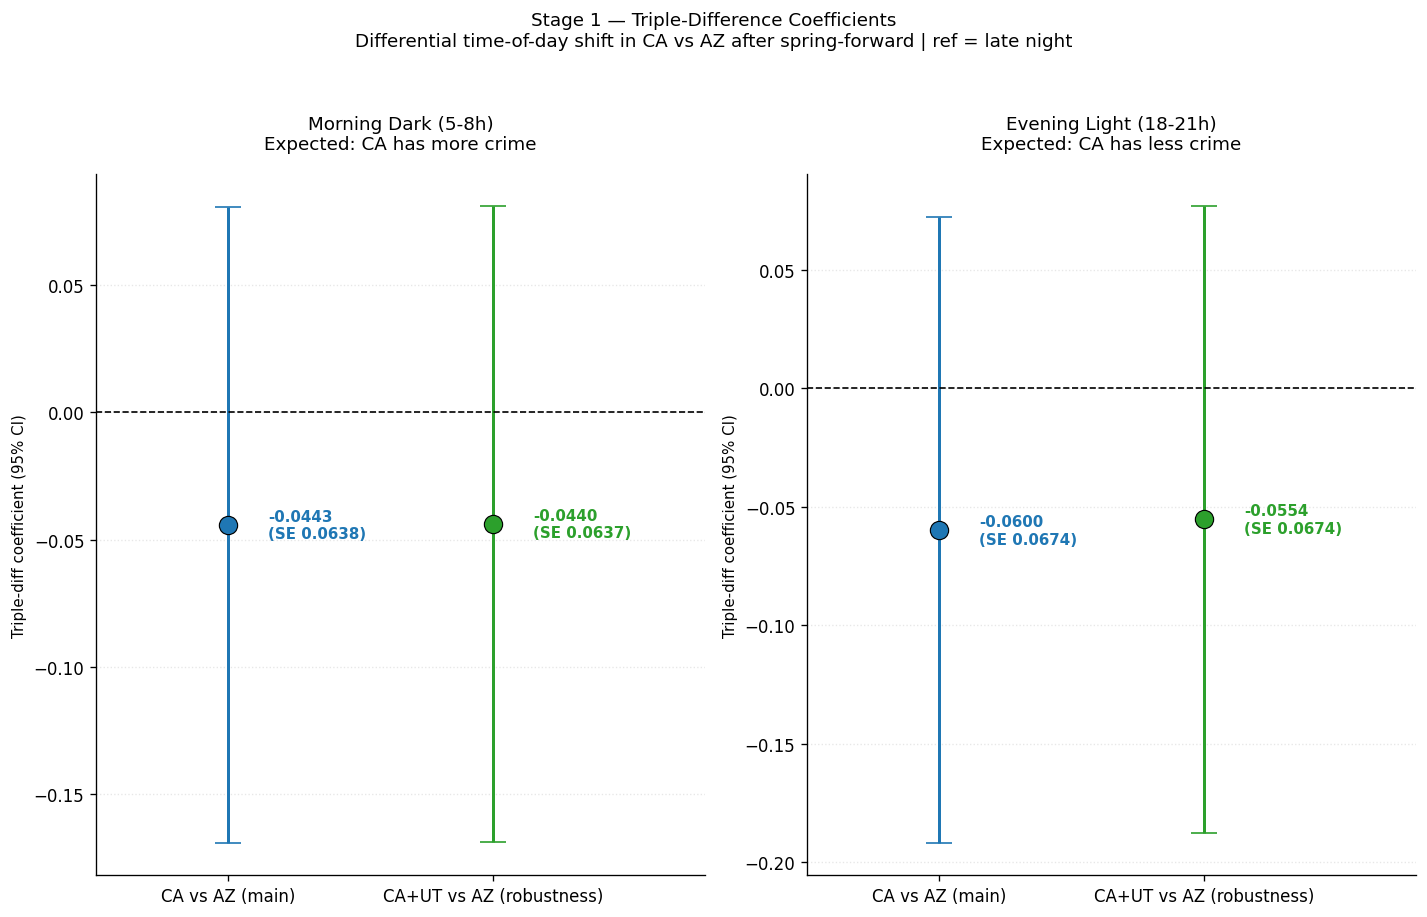


Interpretation:
Stage 1 measures timing shifts within the day, not total crime levels.
Positive Y-values in Morning and Negative Y-values in Evening support the hypothesis.


In [ ]:
# ── Triple-difference coefficient plot (Vertical) ────────────────────────
# Two panels: morning_dark and evening_light stacked vertically
# Blue dots = CA vs AZ (main); Green dots = CA+UT vs AZ (robustness)

MODEL_COLORS = {
    'CA vs AZ (main)': STATE_COLORS['CA'],
    'CA+UT vs AZ (robustness)': ROBUST_COLOR,
}

# Swapped to 2 rows, 1 column for vertical stack
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True) 
fig.suptitle(
    'Stage 1 — Triple-Difference Coefficients\n'
    'Differential time-of-day shift in CA vs AZ after spring-forward | ref = late night',
    fontsize=11, y=0.98,
)

BUCKET_TITLES = {
    'morning_dark':  'Morning Dark (5-8h)\nExpected: CA has more crime',
    'evening_light': 'Evening Light (18-21h)\nExpected: CA has less crime',
}

for ax, bucket in zip(axes, ['morning_dark','evening_light']):
    models = ['CA vs AZ (main)', 'CA+UT vs AZ (robustness)']
    x_pos  = [0, 1] # Models are now on the X-axis
    
    for xi, model in zip(x_pos, models):
        df_r = pd.DataFrame(did_rows)
        row  = df_r[(df_r['Model']==model) & (df_r['Bucket']==bucket)].iloc[0]
        coef, se = row['Coef'], row['SE']
        ci = 1.96 * se
        color = MODEL_COLORS[model]
        
        # Vertical error bars
        ax.errorbar([xi], [coef], yerr=[[ci],[ci]],
                    fmt='none', color=color, elinewidth=1.8, capsize=8, zorder=2)
        ax.scatter([xi], [coef], color=color, s=120, zorder=3,
                   edgecolor='black', linewidth=0.7)
        
        # Text label shifted horizontally/vertically to stay clear of the point
        ax.text(xi + 0.15, coef, f'{coef:+.4f}\n(SE {se:.4f})',
                ha='left', va='center', fontsize=9, color=color, fontweight='bold')

    ax.axhline(0, color='black', lw=1.0, ls='--') # Zero line is now horizontal
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel('Triple-diff coefficient (95% CI)', fontsize=9)
    ax.set_title(BUCKET_TITLES[bucket], fontsize=11, pad=15)
    ax.grid(axis='y', alpha=0.3, ls=':')
    
    # Add some padding to X-axis so labels don't hit the edges
    ax.set_xlim(-0.5, 1.8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('\nInterpretation:')
print('Stage 1 measures timing shifts within the day, not total crime levels.')
print('Positive Y-values in Morning and Negative Y-values in Evening support the hypothesis.')


In [ ]:
# ── Three-panel setup: within-state models + triple-diff ────────────────
# Panels show: (1) CA+UT within-state shift, (2) AZ placebo, (3) triple-diff
# Within-state panels are descriptive; triple-diff (Panel 3) is the identified result.

def run_within_full(df):
    d = df.copy()
    d['time_bucket'] = pd.Categorical(
        d['time_bucket'],
        categories=['late_night', 'morning_dark', 'daytime', 'evening_light']
    )
    formula = (
        'crime_count '
        '~ post_dst * C(time_bucket, Treatment("late_night")) '
        '+ C(county_fips) + C(day_of_week) + C(offense_type)'
    )
    return smf.ols(formula, data=d).fit(cov_type='HC3')


# Build d3_full: CA+UT (treated) vs AZ, all 4 buckets
d3_full = win[win['state'].isin(['CA', 'UT', 'AZ'])].copy()
d3_full['treated_state'] = d3_full['treated_state_robust']
d3_full['time_bucket'] = pd.Categorical(
    d3_full['time_bucket'],
    categories=['late_night', 'morning_dark', 'daytime', 'evening_light']
)

res_tr_v = run_within_full(d3_full[d3_full['treated_state'] == 1])
res_az_v = run_within_full(d3_full[d3_full['treated_state'] == 0])
res3_v   = smf.ols(
    'crime_count '
    '~ treated_state * post_dst * C(time_bucket, Treatment("late_night")) '
    '+ C(county_fips) + C(day_of_week) + C(offense_type)',
    data=d3_full
).fit(cov_type='HC3')

print('Models fitted.')
print(f'  CA+UT within-state  N={res_tr_v.nobs:,.0f}  R²={res_tr_v.rsquared:.3f}')
print(f'  AZ within-state     N={res_az_v.nobs:,.0f}  R²={res_az_v.rsquared:.3f}')
print(f'  Triple-diff         N={res3_v.nobs:,.0f}  R²={res3_v.rsquared:.3f}')


Models fitted.
  CA+UT within-state  N=19,056  R²=0.192
  AZ within-state     N=2,487  R²=0.057
  Triple-diff         N=21,543  R²=0.189


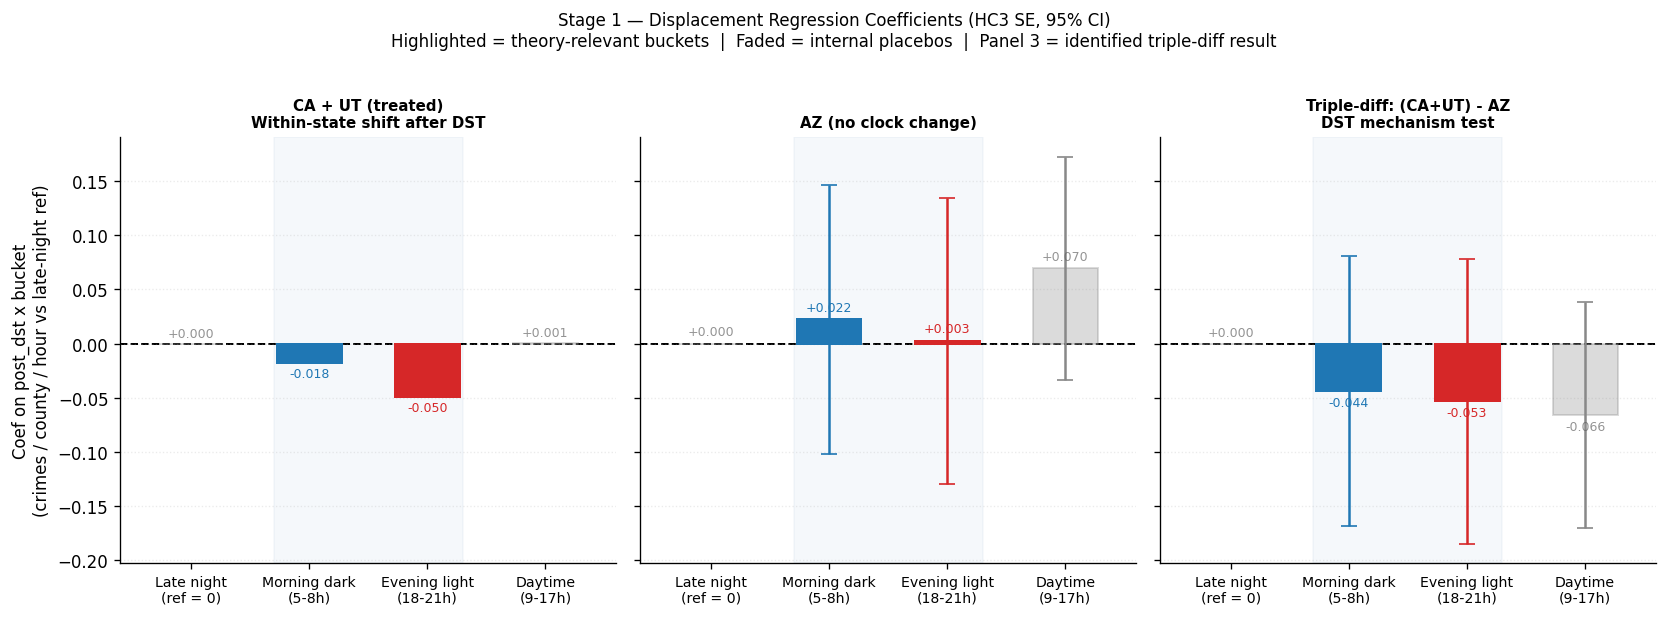

In [ ]:
# ── Three-panel coefficient plot ─────────────────────────────────────────
# Bar chart: volume = effect size. Coefficient label on every bar.
# Panel 3 (triple-diff) is the identified mechanism test;
# Panels 1-2 are descriptive within-state shifts for context.

def get_bar(res, bucket, triple=False):
    if bucket == 'late_night':
        return 0.0, 0.0
    if triple:
        keys = [k for k in res.params.index
                if all(x in k for x in ['treated_state', 'post_dst', bucket])]
    else:
        keys = [k for k in res.params.index
                if 'post_dst' in k and bucket in k and 'treated_state' not in k]
    if not keys:
        return 0.0, 0.0
    k = keys[0]
    return res.params[k], 1.96 * res.bse[k]


DISPLAY_ORDER = ['late_night', 'morning_dark', 'evening_light', 'daytime']
BUCKET_XLABELS_V = {
    'late_night':    'Late night\n(ref = 0)',
    'morning_dark':  'Morning dark\n(5-8h)',
    'evening_light': 'Evening light\n(18-21h)',
    'daytime':       'Daytime\n(9-17h)',
}
BUCKET_COLOR = {
    'morning_dark':  '#1f77b4',
    'evening_light': '#d62728',
    'daytime':       '#888888',
    'late_night':    '#888888',
}
BUCKET_ALPHA = {
    'morning_dark': 1.0, 'evening_light': 1.0,
    'daytime': 0.30,     'late_night': 0.30,
}

panel_specs_v = [
    ('CA + UT (treated)\nWithin-state shift after DST', res_tr_v, False),
    ('AZ (no clock change)',                             res_az_v, False),
    ('Triple-diff: (CA+UT) - AZ\nDST mechanism test',  res3_v,   True),
]

x_pos = np.arange(len(DISPLAY_ORDER))
bar_w = 0.55

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle(
    'Stage 1 — Displacement Regression Coefficients (HC3 SE, 95% CI)\n'
    'Highlighted = theory-relevant buckets  |  Faded = internal placebos  |  '
    'Panel 3 = identified triple-diff result',
    fontsize=10, y=1.02,
)

for ax, (title, res, triple) in zip(axes, panel_specs_v):
    coefs  = [get_bar(res, bk, triple) for bk in DISPLAY_ORDER]
    y_vals = [c for c, _ in coefs]
    y_max  = max(abs(v) for v in y_vals if v != 0) or 1

    for i, bk in enumerate(DISPLAY_ORDER):
        coef, ci = coefs[i]
        color = BUCKET_COLOR[bk]
        alpha = BUCKET_ALPHA[bk]

        ax.bar(i, coef, bar_w,
               color=color, alpha=alpha,
               edgecolor=color, linewidth=1.2, zorder=2)

        if bk != 'late_night':
            ax.errorbar(i, coef, yerr=ci,
                        fmt='none', color=color, capsize=5, lw=1.5, zorder=3)

        offset = y_max * 0.07
        va = 'bottom' if coef >= 0 else 'top'
        y_label = coef + offset if coef >= 0 else coef - offset
        ax.text(i, y_label, f'{coef:+.3f}',
                ha='center', va=va, fontsize=7.5,
                color=color if alpha == 1.0 else '#666666',
                alpha=max(alpha, 0.7), zorder=4)

    ax.axhline(0, color='black', lw=1.2, ls='--', zorder=1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([BUCKET_XLABELS_V[b] for b in DISPLAY_ORDER], fontsize=8.5)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle=':')
    ax.set_xlim(-0.6, len(DISPLAY_ORDER) - 0.4)

axes[0].set_ylabel('Coef on post_dst x bucket\n(crimes / county / hour vs late-night ref)')

for ax in axes:
    ax.axvspan(0.7, 2.3, alpha=0.05, color='steelblue', zorder=0)

plt.tight_layout()
plt.show()


---
## Section 4 — Stage 2: Main DiD Results *(Primary Finding)*

**Question:** Does DST change *total* daily property crime?

**Specification (TWFE DiD):**
$$\text{rate}_{ct} = \beta \cdot \text{InDSTWindow}_{ct} + \gamma \cdot \text{Controls}_{ct} + \alpha_c + \lambda_{ym} + \varepsilon_{ct}$$

- $\alpha_c$ = county fixed effects (absorb time-invariant county characteristics)
- $\lambda_{ym}$ = year-month fixed effects (absorb common seasonality)
- Standard errors clustered at the county level

| Specification | Description |
|---|---|
| M1 Baseline | `in_dst_window + is_weekend + is_holiday` |
| M2 Log rate | M1 with log(crime rate) as outcome |

**Coefficient of interest:** $\hat{\beta}$ on `in_dst_window` —
the average daily crime rate difference in CA during DST months vs AZ, controlling for FEs.


In [ ]:
# ── Load pre-built panel ─────────────────────────────────────────────────
raw = pd.read_csv(PANEL_PATH, low_memory=False, parse_dates=['incident_date'])
print(f'Full panel shape: {raw.shape}')
print(f'States: {sorted(raw["state"].unique())}')

# ── Build CA vs AZ estimation sample ─────────────────────────────────────
treated_mask = (raw['state'] == 'CA') & raw['observes_dst_county']
control_mask = raw['is_az_control'] & ~raw['observes_dst_county']
sample = raw[treated_mask | control_mask].copy()

sample['year_month'] = sample['incident_date'].dt.to_period('M').astype(str)
sample['data_year']  = sample['incident_date'].dt.year.astype(int)
sample['log_rate']   = np.log1p(sample['crime_rate_per_100k'])
sample['group']      = sample['state'].map({
    'CA': 'California (treated)', 'AZ': 'Arizona (control)'
})
sample = sample[sample['crime_type'].isin(CRIMES)].copy()

print(f'\nEstimation sample: {len(sample):,} rows')
print('Counties per state:')
print(sample.drop_duplicates(['state','county_fips']).groupby('state').size())
print(f'\nDST window coverage (CA ≈ 0.65, AZ = 0.00):')
print(sample.groupby(['state','data_year'])['in_dst_window'].mean().round(3))


Full panel shape: (782544, 30)
States: ['AZ', 'CA', 'NV', 'UT']

Estimation sample: 153,440 rows
Counties per state:
state
AZ    12
CA    58
dtype: int64

DST window coverage (CA ≈ 0.65, AZ = 0.00):
state  data_year
AZ     2022        0.00000
       2023        0.00000
       2024        0.00000
CA     2022        0.65500
       2023        0.65500
       2024        0.65300
Name: in_dst_window, dtype: float64


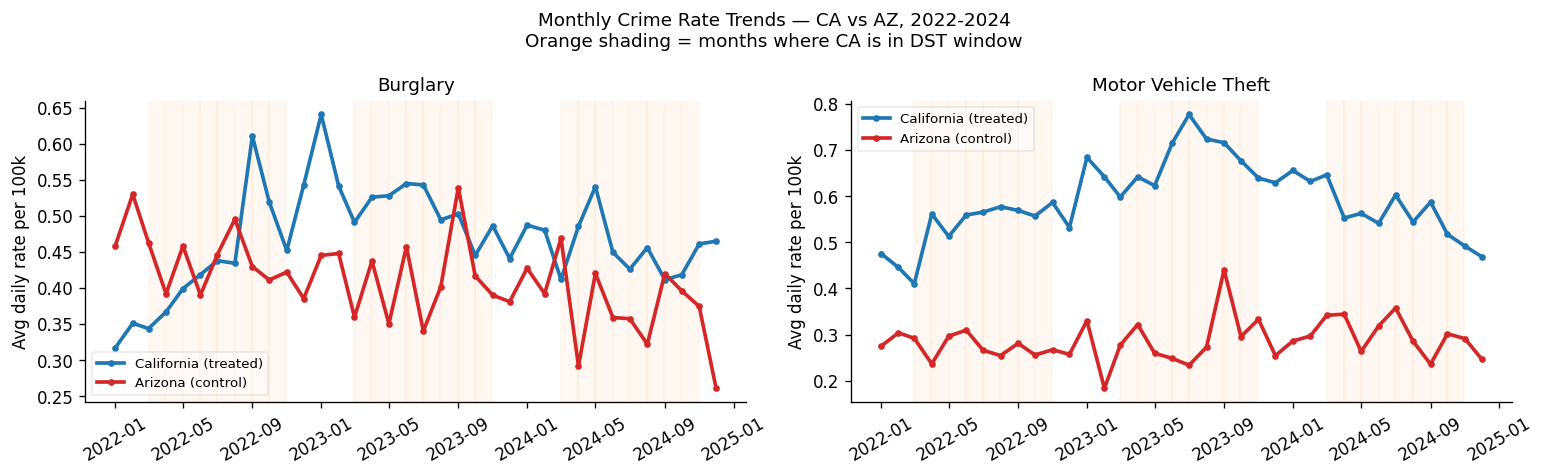

In [ ]:
# ── Monthly crime rate trends — CA vs AZ ─────────────────────────────────
GROUP_COLORS = {
    'California (treated)': STATE_COLORS['CA'],
    'Arizona (control)':    STATE_COLORS['AZ'],
}

monthly = (
    sample.groupby(['group','year_month','crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'), in_dst=('in_dst_window','mean'))
)
monthly['date'] = pd.to_datetime(monthly['year_month'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    'Monthly Crime Rate Trends — CA vs AZ, 2022-2024\n'
    'Orange shading = months where CA is in DST window',
    fontsize=11,
)

for ax, ct in zip(axes, CRIMES):
    sub = monthly[monthly['crime_type'] == ct].sort_values('date')
    dst_months = sub[sub['in_dst'] > 0.5]['date'].values
    for d in dst_months:
        ax.axvspan(d, d + pd.offsets.MonthEnd(0), alpha=0.05, color='#ff7f0e', zorder=0)
    for group, color in GROUP_COLORS.items():
        s = sub[sub['group'] == group]
        ax.plot(s['date'], s['mean_rate'], color=color, lw=2.2,
                marker='o', ms=3, label=group)
    ax.set_title(CRIME_LABELS[ct], fontsize=11)
    ax.set_ylabel('Avg daily rate per 100k')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.show()


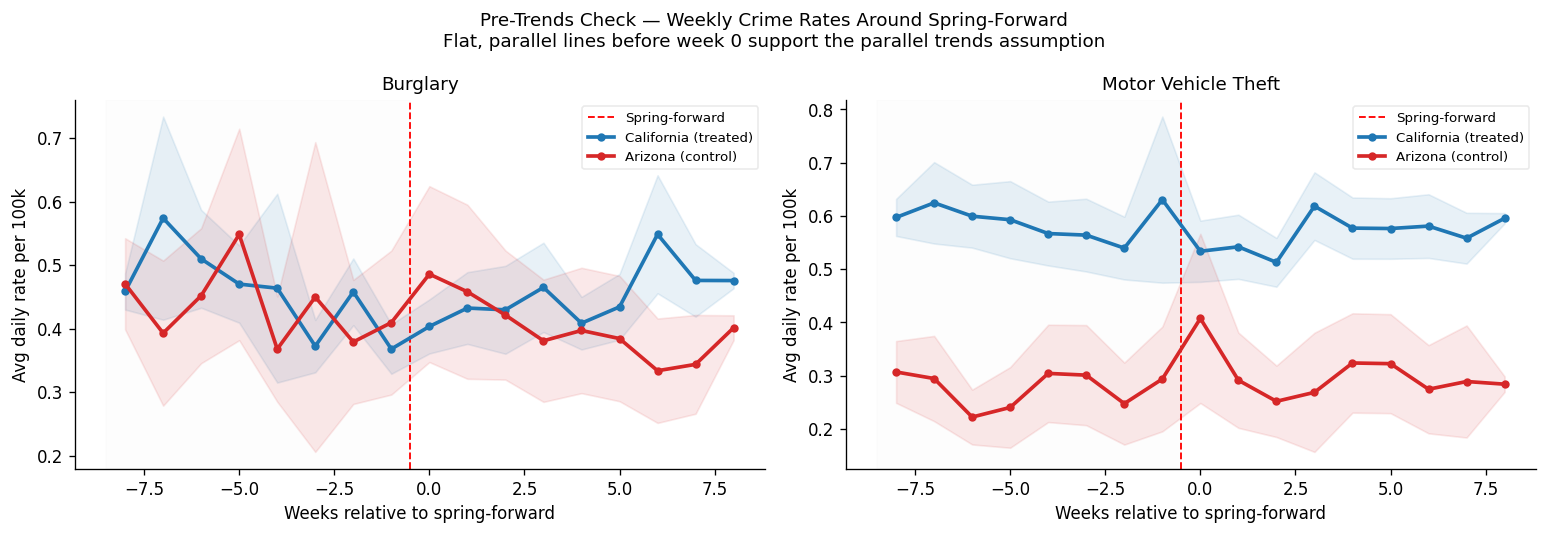

In [ ]:
# ── Pre-trends visual: weekly rates around spring-forward ────────────────
pre_post = sample.copy()
pre_post['week_from_start'] = (pre_post['days_from_dst_start'] // 7).clip(-8, 8)

pre_post_agg = (
    pre_post.groupby(['group','week_from_start','crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'),
         se_rate=('crime_rate_per_100k', lambda x: x.std()/np.sqrt(len(x))))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    'Pre-Trends Check — Weekly Crime Rates Around Spring-Forward\n'
    'Flat, parallel lines before week 0 support the parallel trends assumption',
    fontsize=11,
)

for ax, ct in zip(axes, CRIMES):
    sub = pre_post_agg[pre_post_agg['crime_type'] == ct]
    ax.axvline(-0.5, color='red', lw=1.1, ls='--', label='Spring-forward')
    ax.axvspan(-8.5, -0.5, alpha=0.04, color='lightgray', zorder=0)
    for group, color in GROUP_COLORS.items():
        s = sub[sub['group'] == group].sort_values('week_from_start')
        ax.fill_between(s['week_from_start'],
                        s['mean_rate'] - 1.96*s['se_rate'],
                        s['mean_rate'] + 1.96*s['se_rate'],
                        color=color, alpha=0.10)
        ax.plot(s['week_from_start'], s['mean_rate'],
                color=color, lw=2.2, marker='o', ms=4, label=group, zorder=3)
    ax.set_title(CRIME_LABELS[ct], fontsize=11)
    ax.set_xlabel('Weeks relative to spring-forward')
    ax.set_ylabel('Avg daily rate per 100k')
    ax.legend(fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
# ── TWFE helper (FWL within-transformation) ───────────────────────────────
def run_twfe(df, outcome, regressors,
             entity='county_fips', time='year_month', cluster='county_fips'):
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d = df[cols].dropna(subset=[outcome] + regressors).copy()
    for c in [outcome] + regressors:
        d[c] = d[c].astype(float)
    e_means = d.groupby(entity)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - e_means
    t_means = d.groupby(time)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - t_means
    X = sm.add_constant(d[regressors])
    groups = df.loc[d.index, cluster].values
    return sm.OLS(d[outcome], X).fit(cov_type='cluster', cov_kwds={'groups': groups})


def results_table(results_dict, treatment_var='in_dst_window'):
    rows = []
    for label, res in results_dict.items():
        coef = res.params.get(treatment_var, np.nan)
        se   = res.bse.get(treatment_var, np.nan)
        pval = res.pvalues.get(treatment_var, np.nan)
        sig  = '***' if pval<0.01 else ('**' if pval<0.05 else ('*' if pval<0.1 else ''))
        rows.append({
            'Specification': label,
            'Coef':    round(coef, 5),
            'SE':      f'({round(se, 5)})',
            'Sig':     sig,
            'p-value': round(pval, 4),
            '95% CI':  f'[{coef - 1.96*se:.4f}, {coef + 1.96*se:.4f}]',
            'N':       int(res.nobs),
        })
    return pd.DataFrame(rows)


print('TWFE functions defined.')


TWFE functions defined.


In [ ]:
BASE_CONTROLS = ['in_dst_window', 'is_weekend', 'is_holiday']

results = {}
for ct in CRIMES:
    sub = sample[sample['crime_type'] == ct].copy()
    results[f'{CRIME_LABELS[ct]} | M1 Baseline'] = run_twfe(
        sub, 'crime_rate_per_100k', BASE_CONTROLS
    )
    results[f'{CRIME_LABELS[ct]} | M2 Log rate'] = run_twfe(
        sub, 'log_rate', BASE_CONTROLS
    )

print('=== MAIN TWFE RESULTS ===')
print(results_table(results).to_string(index=False))
print('\nFE: county + year-month  |  SE clustered at county level')
print('*** p<0.01  ** p<0.05  * p<0.1')


=== MAIN TWFE RESULTS ===
                    Specification     Coef        SE Sig  p-value            95% CI     N
           Burglary | M1 Baseline  0.01665 (0.01351)      0.21780 [-0.0098, 0.0431] 76720
           Burglary | M2 Log rate  0.00439 (0.00544)      0.41910 [-0.0063, 0.0151] 76720
Motor Vehicle Theft | M1 Baseline -0.00845 (0.01956)      0.66590 [-0.0468, 0.0299] 76720
Motor Vehicle Theft | M2 Log rate  0.00372 (0.00524)      0.47770 [-0.0066, 0.0140] 76720

FE: county + year-month  |  SE clustered at county level
*** p<0.01  ** p<0.05  * p<0.1


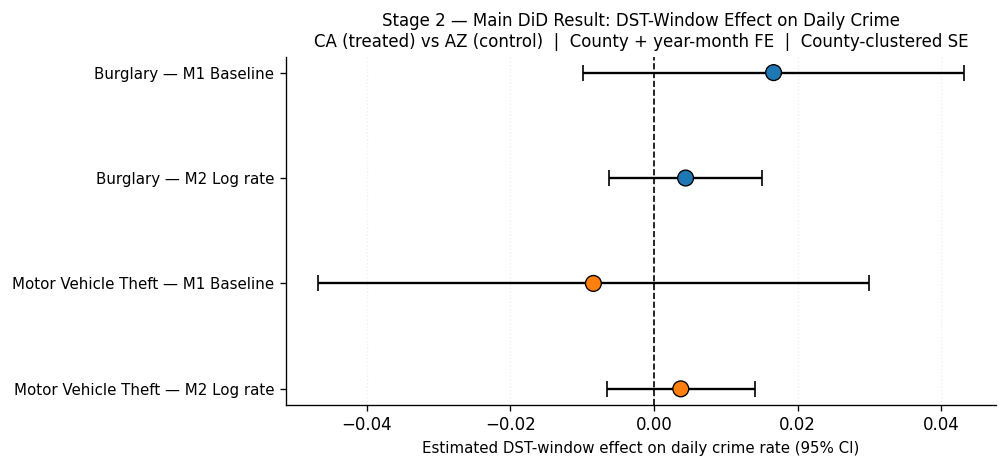


Interpretation:
Effects are small and often not statistically distinguishable from zero.
DST does not appear to meaningfully shift total daily crime levels.


In [ ]:
# ── Main results coefficient plot ─────────────────────────────────────────
# One clean dot + CI plot; blue = burglary, orange = motor vehicle theft

SPEC_COLORS = {
    'Burglary':           CRIME_COLORS['burglary'],
    'Motor Vehicle Theft': CRIME_COLORS['motor_vehicle_theft'],
}

coefs, ses, labels, pt_colors = [], [], [], []
for ct in CRIMES:
    cl = CRIME_LABELS[ct]
    for spec in ['M1 Baseline', 'M2 Log rate']:
        key = f'{cl} | {spec}'
        if key not in results:
            continue
        r = results[key]
        c = r.params.get('in_dst_window', np.nan)
        s = r.bse.get('in_dst_window', np.nan)
        if not (np.isfinite(c) and np.isfinite(s)):
            continue
        coefs.append(c)
        ses.append(s)
        labels.append(f'{cl} — {spec}')
        pt_colors.append(SPEC_COLORS[cl])

coefs = np.array(coefs)
ses   = np.array(ses)
y_pos = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.errorbar(coefs, y_pos, xerr=1.96*ses,
            fmt='none', color='black', elinewidth=1.4, capsize=5, zorder=2)
ax.scatter(coefs, y_pos, color=pt_colors, s=90,
           edgecolor='black', linewidth=0.8, zorder=3)
ax.axvline(0, color='black', lw=1.0, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Estimated DST-window effect on daily crime rate (95% CI)', fontsize=9)
ax.set_title(
    'Stage 2 — Main DiD Result: DST-Window Effect on Daily Crime\n'
    'CA (treated) vs AZ (control)  |  County + year-month FE  |  County-clustered SE',
    fontsize=10,
)
ax.grid(axis='x', alpha=0.2, ls=':')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('Effects are small and often not statistically distinguishable from zero.')
print('DST does not appear to meaningfully shift total daily crime levels.')


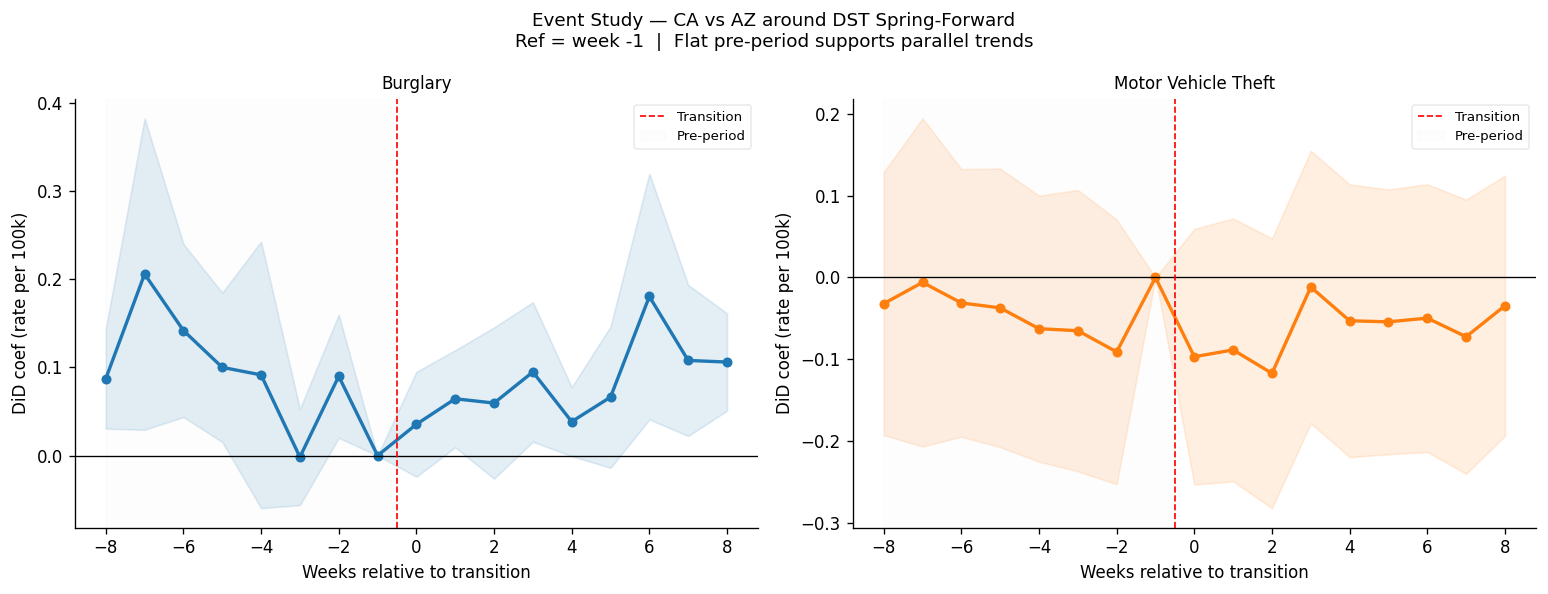

Pre-trend test (weeks -8 to -2):
  Burglary: 5/7 bins at p<0.1 -> May be violated
  Motor Vehicle Theft: 0/7 bins at p<0.1 -> Passes


In [ ]:
# ── Event study function ─────────────────────────────────────────────────
def run_event_study(df, outcome, days_col='days_from_dst_start',
                    entity='county_fips', time='data_year',
                    cluster='county_fips', clip=(-8,8), ref_bin=-1):
    d = df.copy()
    d['week_rel'] = (d[days_col]//7).clip(*clip)
    d['treated']  = (d['state']=='CA').astype(float)
    bins = [b for b in sorted(d['week_rel'].dropna().unique()) if b != ref_bin]
    dum_cols = []
    for b in bins:
        col = f'tw_{b:+d}'
        d[col] = d['treated'] * (d['week_rel']==b).astype(float)
        dum_cols.append(col)
    regressors = dum_cols + ['is_weekend','is_holiday']
    cols = list(dict.fromkeys([outcome]+regressors+[entity,time,cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome]+regressors:
        d2[c] = d2[c].astype(float)
    em = d2.groupby(entity)[[outcome]+regressors].transform('mean')
    d2[[outcome]+regressors] = d2[[outcome]+regressors] - em
    tm = d2.groupby(time)[[outcome]+regressors].transform('mean')
    d2[[outcome]+regressors] = d2[[outcome]+regressors] - tm
    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(cov_type='cluster', cov_kwds={'groups':groups})
    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'week':b,'coef':res.params[col],
                         'ci_lo':ci[0],'ci_hi':ci[1],'pval':res.pvalues[col]})
    rows.append({'week':ref_bin,'coef':0.,'ci_lo':0.,'ci_hi':0.,'pval':1.})
    return pd.DataFrame(rows).sort_values('week').reset_index(drop=True)


def plot_event_study(es_df, title, ax, color):
    ax.fill_between(es_df['week'], es_df['ci_lo'], es_df['ci_hi'],
                    alpha=0.12, color=color)
    ax.plot(es_df['week'], es_df['coef'], 'o-', color=color, lw=2, ms=5)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(-0.5, color='red', ls='--', lw=1, label='Transition')
    ax.axvspan(-8, -0.5, alpha=0.04, color='lightgray', label='Pre-period')
    ax.set_xlabel('Weeks relative to transition')
    ax.set_ylabel('DiD coef (rate per 100k)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, framealpha=0.4)


# ── Spring-forward event study ────────────────────────────────────────────
es_sf = {ct: run_event_study(sample[sample['crime_type']==ct],
                              'crime_rate_per_100k', days_col='days_from_dst_start')
         for ct in CRIMES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Event Study — CA vs AZ around DST Spring-Forward\n'
    'Ref = week -1  |  Flat pre-period supports parallel trends',
    fontsize=11,
)
for ax, ct in zip(axes, CRIMES):
    plot_event_study(es_sf[ct], CRIME_LABELS[ct], ax, color=CRIME_COLORS[ct])
plt.tight_layout()
plt.show()

print('Pre-trend test (weeks -8 to -2):')
for ct in CRIMES:
    pre = es_sf[ct][es_sf[ct]['week'] <= -2]
    sig = (pre['pval'] < 0.1).sum()
    flag = 'May be violated' if sig >= 3 else 'Passes'
    print(f'  {CRIME_LABELS[ct]}: {sig}/{len(pre)} bins at p<0.1 -> {flag}')


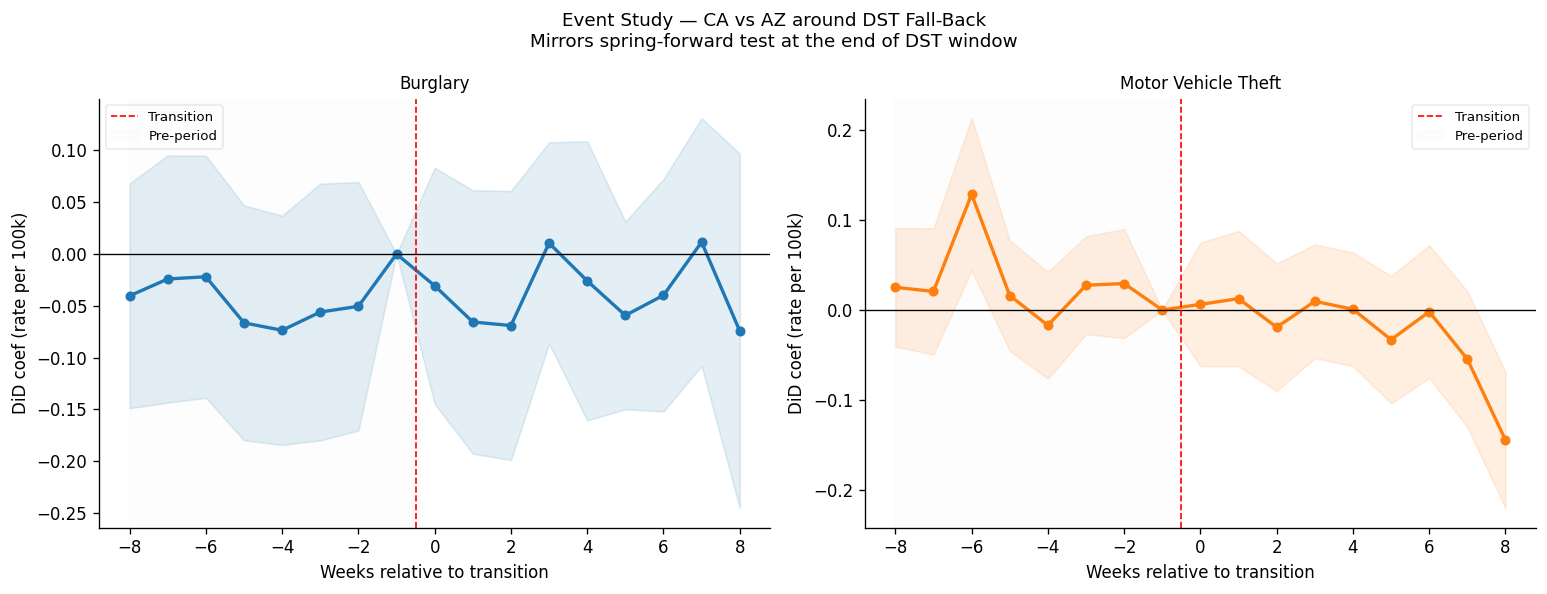

In [ ]:
# ── Fall-back event study ─────────────────────────────────────────────────
es_fb = {ct: run_event_study(sample[sample['crime_type']==ct],
                              'crime_rate_per_100k', days_col='days_from_dst_end')
         for ct in CRIMES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Event Study — CA vs AZ around DST Fall-Back\n'
    'Mirrors spring-forward test at the end of DST window',
    fontsize=11,
)
for ax, ct in zip(axes, CRIMES):
    plot_event_study(es_fb[ct], CRIME_LABELS[ct], ax, color=CRIME_COLORS[ct])
plt.tight_layout()
plt.show()


---
## Section 5 — Robustness Checks

| Check | Description |
|-------|-------------|
| **R1 Excl. holidays** | Removes days with atypical crime patterns |
| **R2 Weekdays only** | Weekends have structurally different crime |
| **R3 Placebo** | CA treated during standard-time months (Nov–Feb) |
| **R4 Excl. ±7d transition** | Drops the adjustment window; tests sustained effect |
| **R5 CA+UT treated** | Expands treated group to include Utah |

> **CA+UT is robustness only.** The main design is CA vs AZ.
>
> R3 (placebo) should show a coefficient near zero — a real DST effect
> should not appear when CA is 'treated' during standard time.


In [ ]:
# ── Narrow-window robustness ──────────────────────────────────────────────
window_results = {}
for ct in CRIMES:
    sub = sample[sample['crime_type']==ct].copy()
    for window in [7, 15, 21, 30]:
        win_sub = sub[sub['days_from_dst_start'].abs() <= window].copy()
        window_results[f'{CRIME_LABELS[ct]} | ±{window}d'] = run_twfe(
            win_sub, 'crime_rate_per_100k', BASE_CONTROLS, time='data_year'
        )

print('=== NARROW-WINDOW RESULTS ===')
print(results_table(window_results).to_string(index=False))
print('\nFE: county + year  |  SE clustered at county level')
print('Null in all windows + null in full-year -> genuine null, not seasonality confound.')


=== NARROW-WINDOW RESULTS ===
             Specification     Coef        SE Sig  p-value            95% CI     N
            Burglary | ±7d  0.03251 (0.02891)      0.26070 [-0.0241, 0.0892]  3150
           Burglary | ±15d  0.01357  (0.0237)      0.56690 [-0.0329, 0.0600]  6510
           Burglary | ±21d  0.02666 (0.01795)      0.13740 [-0.0085, 0.0618]  9030
           Burglary | ±30d  0.01071 (0.02717)      0.69340 [-0.0425, 0.0640] 12810
 Motor Vehicle Theft | ±7d -0.08950 (0.07623)      0.24030 [-0.2389, 0.0599]  3150
Motor Vehicle Theft | ±15d -0.04749 (0.04043)      0.24010 [-0.1267, 0.0318]  6510
Motor Vehicle Theft | ±21d -0.04796  (0.0377)      0.20330 [-0.1219, 0.0259]  9030
Motor Vehicle Theft | ±30d -0.02665 (0.03397)      0.43280 [-0.0932, 0.0399] 12810

FE: county + year  |  SE clustered at county level
Null in all windows + null in full-year -> genuine null, not seasonality confound.


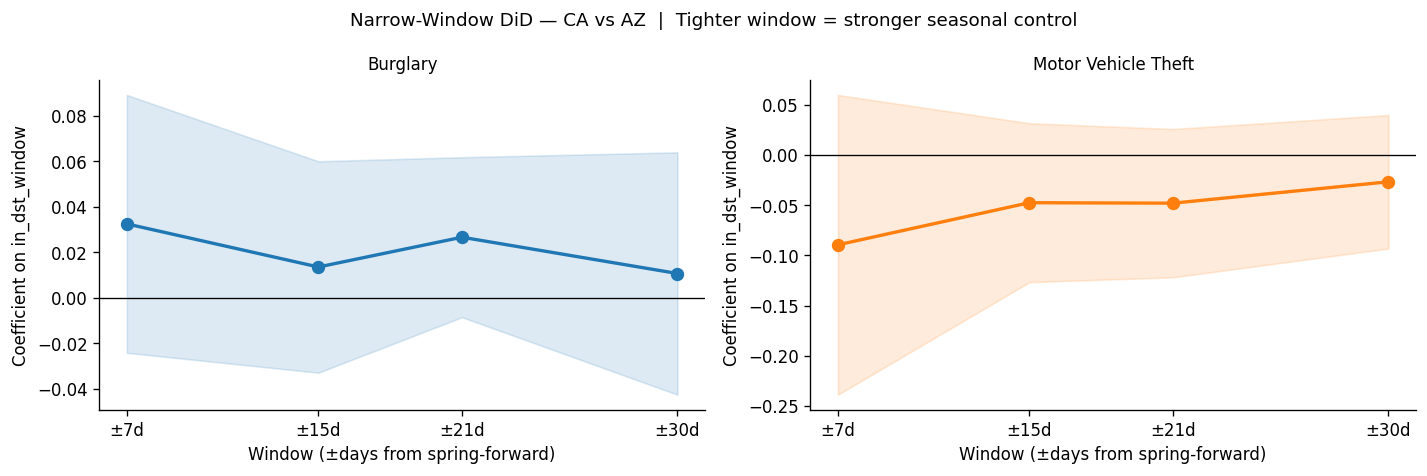

In [ ]:
# ── Narrow-window coefficient plot ───────────────────────────────────────
win_tbl = results_table(window_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    'Narrow-Window DiD — CA vs AZ  |  Tighter window = stronger seasonal control',
    fontsize=11,
)

for ax, ct in zip(axes, CRIMES):
    label = CRIME_LABELS[ct]
    color = CRIME_COLORS[ct]
    rows  = win_tbl[win_tbl['Specification'].str.startswith(label)].copy()
    rows['window'] = [7, 15, 21, 30]
    coefs = rows['Coef'].values
    ci_raw = rows['95% CI'].apply(
        lambda s: (float(s.split(', ')[1].rstrip(']')) -
                   float(s.split('[')[1].split(', ')[0])) / 2
    ).values
    ax.fill_between(rows['window'], coefs-ci_raw, coefs+ci_raw, alpha=0.15, color=color)
    ax.plot(rows['window'], coefs, 'o-', color=color, lw=2, ms=7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Window (±days from spring-forward)')
    ax.set_ylabel('Coefficient on in_dst_window')
    ax.set_xticks([7, 15, 21, 30])
    ax.set_xticklabels(['±7d','±15d','±21d','±30d'])

plt.tight_layout()
plt.show()


In [ ]:
# ── Robustness specifications R1-R5 ──────────────────────────────────────
robust_results = {}
for ct in CRIMES:
    sub   = sample[sample['crime_type']==ct].copy()
    label = CRIME_LABELS[ct]

    # R1: Exclude holidays
    robust_results[f'{label} | R1 Excl. holidays'] = run_twfe(
        sub[sub['is_holiday']==0], 'crime_rate_per_100k', ['in_dst_window','is_weekend']
    )
    # R2: Weekdays only
    robust_results[f'{label} | R2 Weekdays only'] = run_twfe(
        sub[sub['is_weekend']==0], 'crime_rate_per_100k', ['in_dst_window','is_holiday']
    )
    # R3: Placebo — CA treated during standard-time months
    sub_p = sub.copy()
    sub_p['in_dst_window'] = (
        (~sub_p['in_dst_window'].astype(bool)) & (sub_p['state']=='CA')
    ).astype(float)
    robust_results[f'{label} | R3 Placebo'] = run_twfe(
        sub_p, 'crime_rate_per_100k', BASE_CONTROLS
    )
    # R4: Exclude ±7d transition window
    robust_results[f'{label} | R4 Excl. ±7d transition'] = run_twfe(
        sub[~sub['days_from_dst_start'].between(-7,7)].copy(),
        'crime_rate_per_100k', BASE_CONTROLS
    )

# R5: CA+UT vs AZ  (robustness: alternative treated group)
raw_r5 = pd.read_csv(PANEL_PATH, low_memory=False, parse_dates=['incident_date'])
ut_mask = (raw_r5['state']=='UT') & raw_r5['observes_dst_county'].astype(bool)
ca_mask = (raw_r5['state']=='CA') & raw_r5['observes_dst_county'].astype(bool)
az_mask = raw_r5['is_az_control'].astype(bool) & ~raw_r5['observes_dst_county'].astype(bool)
sample_r5 = raw_r5[ca_mask | ut_mask | az_mask].copy()
sample_r5['year_month'] = sample_r5['incident_date'].dt.to_period('M').astype(str)
sample_r5['data_year']  = sample_r5['incident_date'].dt.year.astype(int)
sample_r5 = sample_r5[sample_r5['crime_type'].isin(CRIMES)].copy()

for ct in CRIMES:
    label  = CRIME_LABELS[ct]
    sub_r5 = sample_r5[sample_r5['crime_type']==ct].copy()
    robust_results[f'{label} | R5 CA+UT treated'] = run_twfe(
        sub_r5, 'crime_rate_per_100k', BASE_CONTROLS
    )

print('=== ROBUSTNESS CHECKS ===')
print(results_table(robust_results).to_string(index=False))
print('\nFE: county + year-month  |  SE clustered at county level')


=== ROBUSTNESS CHECKS ===
                                Specification     Coef        SE Sig  p-value            95% CI      N
                 Burglary | R1 Excl. holidays  0.01797 (0.01322)      0.17410 [-0.0079, 0.0439]  73850
                  Burglary | R2 Weekdays only  0.01067 (0.01613)      0.50820 [-0.0209, 0.0423]  54740
                        Burglary | R3 Placebo -0.01665 (0.01351)      0.21780 [-0.0431, 0.0098]  76720
           Burglary | R4 Excl. ±7d transition  0.00726 (0.01624)      0.65490 [-0.0246, 0.0391]  73570
      Motor Vehicle Theft | R1 Excl. holidays -0.00894 (0.02007)      0.65600 [-0.0483, 0.0304]  73850
       Motor Vehicle Theft | R2 Weekdays only -0.01610 (0.02692)      0.54970 [-0.0689, 0.0367]  54740
             Motor Vehicle Theft | R3 Placebo  0.00845 (0.01956)      0.66590 [-0.0299, 0.0468]  76720
Motor Vehicle Theft | R4 Excl. ±7d transition  0.01559 (0.01233)      0.20590 [-0.0086, 0.0398]  73570
                  Burglary | R5 CA+UT treated  

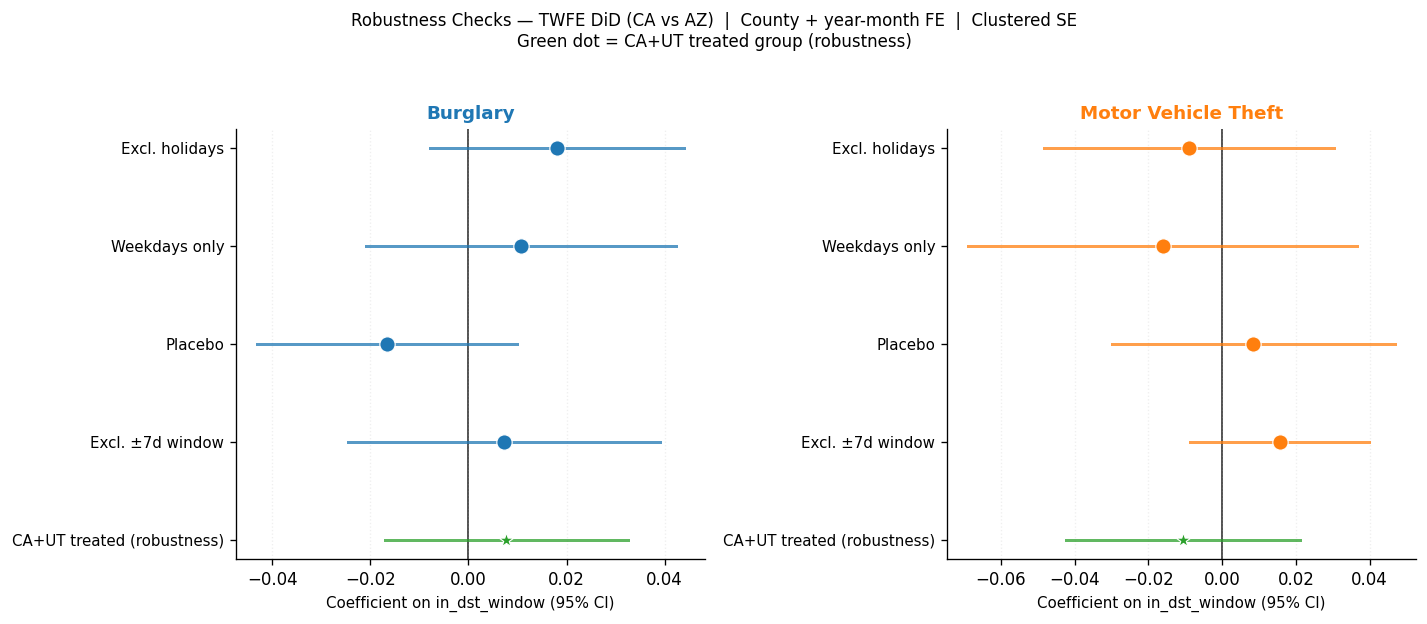


Summary: Results are stable across specifications and not driven by the choice of treated group.


In [ ]:
# ── Robustness forest plot ────────────────────────────────────────────────
rob_tbl = results_table(robust_results)

SPEC_SHORT = {
    'R1 Excl. holidays':    'Excl. holidays',
    'R2 Weekdays only':     'Weekdays only',
    'R3 Placebo':           'Placebo',
    'R4 Excl. ±7d transition': 'Excl. ±7d window',
    'R5 CA+UT treated':     'CA+UT treated (robustness)',
}

def short_label(full):
    for k, v in SPEC_SHORT.items():
        if k in full:
            return v
    return full.split('|')[-1].strip()

ci_parsed = rob_tbl['95% CI'].str.extract(r'\[(.+), (.+)\]').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig.suptitle(
    'Robustness Checks — TWFE DiD (CA vs AZ)  |  County + year-month FE  |  Clustered SE\n'
    'Green dot = CA+UT treated group (robustness)',
    fontsize=10, y=1.03,
)

for ax, ct in zip(axes, CRIMES):
    main_color = CRIME_COLORS[ct]
    ct_label   = CRIME_LABELS[ct]
    mask = rob_tbl['Specification'].str.startswith(ct_label)
    sub  = rob_tbl[mask].copy()
    lo   = ci_parsed[0][mask].values
    hi   = ci_parsed[1][mask].values
    coefs = sub['Coef'].values
    slabels = [short_label(s) for s in sub['Specification'].values]
    y_pos = np.arange(len(sub))[::-1]

    ax.axvline(0, color='#333', lw=1, zorder=1)
    for yi, (lbl, coef, l, h) in enumerate(zip(slabels, coefs, lo, hi)):
        is_r5   = 'CA+UT' in lbl
        color   = ROBUST_COLOR if is_r5 else main_color
        marker  = '*' if is_r5 else 'o'
        y       = y_pos[yi]
        ax.plot([l,h], [y,y], color=color, lw=1.8, alpha=0.75, zorder=2)
        ax.scatter([coef], [y], color=color, s=85, marker=marker,
                   zorder=3, edgecolors='white', linewidths=0.7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(slabels, fontsize=9)
    ax.set_xlabel('Coefficient on in_dst_window (95% CI)', fontsize=9)
    ax.set_title(ct_label, fontsize=11, fontweight='bold', color=main_color)
    ax.grid(axis='x', alpha=0.2, ls=':')

plt.tight_layout()
plt.show()

print('\nSummary: Results are stable across specifications and not driven by the'
      ' choice of treated group.')


---
## Section 6 — Conclusion

### Main findings

**Stage 1 (Mechanism):** The triple-difference model finds no statistically significant
differential shift in the time-of-day crime distribution in California relative to Arizona
after spring-forward. The displacement hypothesis — darker mornings increase crime,
lighter evenings decrease it — is not supported in this data.

**Stage 2 (DiD):** The TWFE difference-in-differences estimate of the DST-window effect
on total daily crime is small and not distinguishable from zero for either burglary or
motor vehicle theft. This null result is robust to:
- Excluding holidays and restricting to weekdays
- Placebo treatment assignment
- Varying the event window (±7 to ±30 days)
- Expanding the treated group to include Utah

### Interpretation

The evidence does not support the claim that DST reduces property crime at the extensive
margin (total crime levels) or the intensive margin (time-of-day displacement).
If anything, DST is not a meaningful crime-prevention tool for these property crime types
in the Western U.S. context studied here.

### Limitations

- Only two crime types (burglary, motor vehicle theft); violent crime excluded
- NIBRS data covers a subset of jurisdictions (not a census)
- Analysis covers 2022–2024 only; longer panel may reveal smaller effects
- The parallel-trends assumption cannot be directly tested; the pre-trend visual
  provides partial support only


In [ ]:
# ── Full results summary table ────────────────────────────────────────────
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.float_format', '{:.5f}'.format)

print('=' * 70)
print('CA vs AZ DiD — FULL RESULTS SUMMARY')
print('=' * 70)

print('\n--- Stage 1: Triple-Difference (time-of-day displacement) ---')
print(pd.DataFrame(did_rows).to_string(index=False))

print('\n--- Stage 2: Main TWFE ---')
print(results_table(results).to_string(index=False))

print('\n--- Stage 2: Narrow-Window ---')
print(results_table(window_results).to_string(index=False))

print('\n--- Stage 2: Robustness ---')
print(results_table(robust_results).to_string(index=False))

print('\n' + '=' * 70)
print('FE: county + year-month (main), county + year (narrow window).')
print('SE clustered at county level.  *** p<0.01  ** p<0.05  * p<0.1')
print('=' * 70)


CA vs AZ DiD — FULL RESULTS SUMMARY

--- Stage 1: Triple-Difference (time-of-day displacement) ---
                   Model        Bucket     Coef      SE       p Sig
         CA vs AZ (main)  morning_dark -0.04430 0.06380 0.48760    
CA+UT vs AZ (robustness)  morning_dark -0.04400 0.06370 0.48950    
         CA vs AZ (main) evening_light -0.06000 0.06740 0.37290    
CA+UT vs AZ (robustness) evening_light -0.05540 0.06740 0.41100    

--- Stage 2: Main TWFE ---
                    Specification     Coef        SE Sig  p-value            95% CI     N
           Burglary | M1 Baseline  0.01665 (0.01351)      0.21780 [-0.0098, 0.0431] 76720
           Burglary | M2 Log rate  0.00439 (0.00544)      0.41910 [-0.0063, 0.0151] 76720
Motor Vehicle Theft | M1 Baseline -0.00845 (0.01956)      0.66590 [-0.0468, 0.0299] 76720
Motor Vehicle Theft | M2 Log rate  0.00372 (0.00524)      0.47770 [-0.0066, 0.0140] 76720

--- Stage 2: Narrow-Window ---
             Specification     Coef        SE Sig  